# 🎥 Video 08: Molecular Similarity & Similarity Searching
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 3 — Molecular Fingerprints (Topics 18 & 19)
* **Target Audience:** Cheminformatics Engineers, Screening Scientists, Computational Chemists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | The Similar Property Principle: Why Molecular Similarity Matters
* **04:30 - 09:30** | Mathematical Similarity Metrics: Tanimoto (Jaccard), Dice, Cosine, Tversky
* **09:30 - 14:00** | Pairwise Similarity Matrices & Distance Computation
* **14:00 - 19:30** | High-Speed Library Screening with `DataStructs.BulkTanimotoSimilarity`
* **19:30 - 24:30** | Building a "Find Similar Drugs" Search Engine (Top-K Ranking)
* **24:30 - 27:30** | Atom-Level Similarity Attribution: Riniker & Landrum Similarity Maps
* **27:30 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Understand Johnson & Maggiora's **Similar Property Principle**: Structurally similar molecules exhibit similar biological activities.
2. Master mathematical definitions: Tanimoto ($T_c = \frac{c}{a + b - c}$), Dice, and asymmetric Tversky index.
3. Compute library-scale similarity in milliseconds using C++ accelerated `BulkTanimotoSimilarity`.
4. Build a query-to-library similarity search pipeline that returns ranked 2D structures.
5. Generate similarity maps highlighting the atoms responsible for similarity to a query drug.

In [1]:
# Step 0: Imports and Environment Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.Chem.Draw import SimilarityMaps, IPythonConsole
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IPythonConsole.ipython_useSVG = True

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. The Chemistry & Math of Molecular Similarity
Given two molecular bit vectors $A$ and $B$:
* $a$ = Number of bits set in molecule $A$
* $b$ = Number of bits set in molecule $B$
* $c$ = Number of shared bits common to both $A$ and $B$ (bitwise AND)

### Similarity Coefficients:
1. **Tanimoto (Jaccard) Index:**
   $$T(A, B) = \frac{c}{a + b - c}$$
   Range $[0, 1]$. In medicinal chemistry, a Tanimoto similarity $\ge 0.85$ (using ECFP4) strongly suggests similar biological activity.
2. **Dice Similarity:**
   $$D(A, B) = \frac{2c}{a + b}$$
3. **Cosine Similarity:**
   $$\text{Cos}(A, B) = \frac{c}{\sqrt{a \times b}}$$

In [2]:
# Compute pairwise similarities for 3 kinase inhibitors
drugs = {
    "Gefitinib": Chem.MolFromSmiles("COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"),
    "Erlotinib": Chem.MolFromSmiles("C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1"),
    "Aspirin": Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
}

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = {name: mfpgen.GetFingerprint(m) for name, m in drugs.items()}

# Pairwise comparisons
sim_gef_erl = DataStructs.TanimotoSimilarity(fps["Gefitinib"], fps["Erlotinib"])
sim_gef_asp = DataStructs.TanimotoSimilarity(fps["Gefitinib"], fps["Aspirin"])

print(f"Tanimoto Similarity (Gefitinib vs Erlotinib): {sim_gef_erl:.4f}  (High - Both EGFR inhibitors)")
print(f"Tanimoto Similarity (Gefitinib vs Aspirin):   {sim_gef_asp:.4f}  (Low - Completely distinct)")

Tanimoto Similarity (Gefitinib vs Erlotinib): 0.4079  (High - Both EGFR inhibitors)
Tanimoto Similarity (Gefitinib vs Aspirin):   0.0769  (Low - Completely distinct)


## 2. Comparing Similarity Metrics
Let's see how Tanimoto, Dice, and Cosine values compare on the same pair of molecules.

In [3]:
fp1, fp2 = fps["Gefitinib"], fps["Erlotinib"]

tanimoto = DataStructs.TanimotoSimilarity(fp1, fp2)
dice = DataStructs.DiceSimilarity(fp1, fp2)
cosine = DataStructs.CosineSimilarity(fp1, fp2)

print(f"Tanimoto: {tanimoto:.4f}")
print(f"Dice:     {dice:.4f}  (Always >= Tanimoto)")
print(f"Cosine:   {cosine:.4f}")

Tanimoto: 0.4079
Dice:     0.5794  (Always >= Tanimoto)
Cosine:   0.5838


## 3. High-Speed Screening: `BulkTanimotoSimilarity`
When searching a library of $100,000+$ molecules, calculating similarity in a Python `for` loop is slow.
`DataStructs.BulkTanimotoSimilarity(query_fp, library_fps)` runs entirely in optimized C++ vector instructions!

In [4]:
# Load real EGFR dataset
candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path:
    df_lib = pd.read_csv(csv_path).head(500) # Sample 500 compounds
    mols = []
    valid_indices = []
    
    for i, s in enumerate(df_lib["smiles"]):
        m = Chem.MolFromSmiles(s)
        if m:
            mols.append(m)
            valid_indices.append(i)
            
    df_clean = df_lib.iloc[valid_indices].reset_index(drop=True)
    lib_fps = [mfpgen.GetFingerprint(m) for m in mols]
    print(f"✅ Generated fingerprints for {len(lib_fps)} library compounds.")

✅ Generated fingerprints for 500 library compounds.


## 4. Building a "Find Similar Drugs" Search Engine
Let's build a clean function that takes any query drug SMILES, screens the library in milliseconds, and returns the top-K most similar candidates!

=== 🎯 TOP 6 SIMILAR HITS TO ERLOTINIB ===


,Rank,ChEMBL_ID,Tanimoto_Similarity,pIC50
0,1,CHEMBL3741490,0.9038,9.000000
1,2,CHEMBL3622617,0.7143,8.744727
2,3,CHEMBL598797,0.6719,8.619789
3,4,CHEMBL3622632,0.6522,8.920819
4,5,CHEMBL3360608,0.6197,9.585027
5,6,CHEMBL3355880,0.6197,9.251812


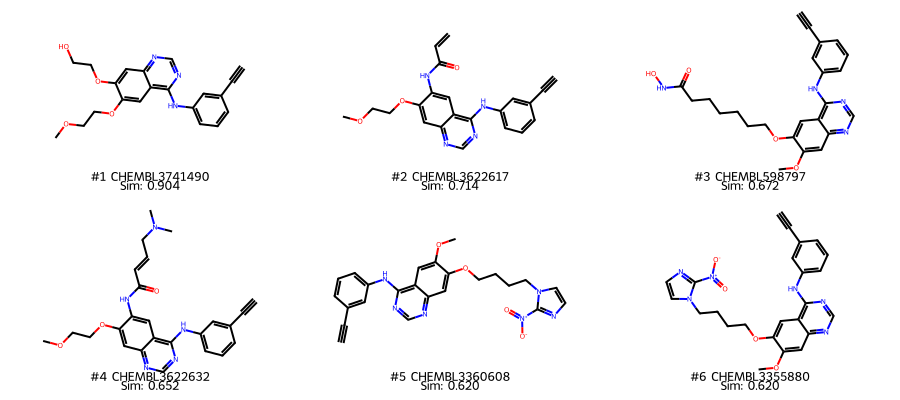

In [5]:
def find_similar_molecules(query_smiles, library_mols, library_fps, library_df, top_k=5):
    query_mol = Chem.MolFromSmiles(query_smiles)
    if not query_mol:
        raise ValueError("Invalid query SMILES!")
        
    query_fp = mfpgen.GetFingerprint(query_mol)
    
    # Fast bulk Tanimoto similarity
    sim_scores = DataStructs.BulkTanimotoSimilarity(query_fp, library_fps)
    
    # Rank by similarity descending
    top_indices = np.argsort(sim_scores)[::-1][:top_k]
    
    results = []
    hit_mols = []
    legends = []
    
    for rank, idx in enumerate(top_indices, 1):
        score = sim_scores[idx]
        cid = library_df.iloc[idx]["molecule_chembl_id"]
        smi = library_df.iloc[idx]["smiles"]
        p_ic50 = library_df.iloc[idx].get("pIC50", "N/A")
        
        results.append({
            "Rank": rank,
            "ChEMBL_ID": cid,
            "Tanimoto_Similarity": round(score, 4),
            "pIC50": p_ic50,
            "SMILES": smi
        })
        hit_mols.append(library_mols[idx])
        legends.append(f"#{rank} {cid}\nSim: {score:.3f}")
        
    df_results = pd.DataFrame(results)
    return df_results, hit_mols, legends

# Search using Erlotinib as the query drug
erlotinib_smi = "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1"
df_hits, hit_mols, hit_legends = find_similar_molecules(
    erlotinib_smi, mols, lib_fps, df_clean, top_k=6
)

print("=== 🎯 TOP 6 SIMILAR HITS TO ERLOTINIB ===")
display(df_hits[["Rank", "ChEMBL_ID", "Tanimoto_Similarity", "pIC50"]])

# Visualize top hits
Draw.MolsToGridImage(hit_mols, legends=hit_legends, molsPerRow=3, subImgSize=(300, 200))

## 5. Visualizing Similarity Maps (Riniker & Landrum)
Why are two molecules similar? Which atoms contribute most to their high Tanimoto score?
**Similarity Maps** compute atom-level weightings and render a contour heatmap across the 2D chemical structure!

In [6]:
# Create a similarity map for Erlotinib relative to Gefitinib
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

ref_mol = Chem.MolFromSmiles("COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4") # Gefitinib
probe_mol = Chem.MolFromSmiles("C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1") # Erlotinib

d2d_sim = rdMolDraw2D.MolDraw2DSVG(450, 350)
SimilarityMaps.GetSimilarityMapForFingerprint(
    ref_mol, probe_mol, SimilarityMaps.GetMorganFingerprint, draw2d=d2d_sim
)
d2d_sim.FinishDrawing()
SVG(d2d_sim.GetDrawingText())

[19:16:06] DEPRECATION WARNING: please use MorganGenerator
[19:16:06] DEPRECATION WARNING: please use MorganGenerator


## 6. 🎯 Video Hands-On Challenge & Solution
### Problem:
1. Plot the histogram of all 500 Tanimoto similarity scores against Erlotinib.
2. Determine how many molecules in the library have a Tanimoto similarity $\ge 0.60$.
3. Compute the mean and maximum similarity score across the library.

Molecules with Tanimoto >= 0.60: 13
Mean similarity:                0.3010
Maximum similarity:             0.9038


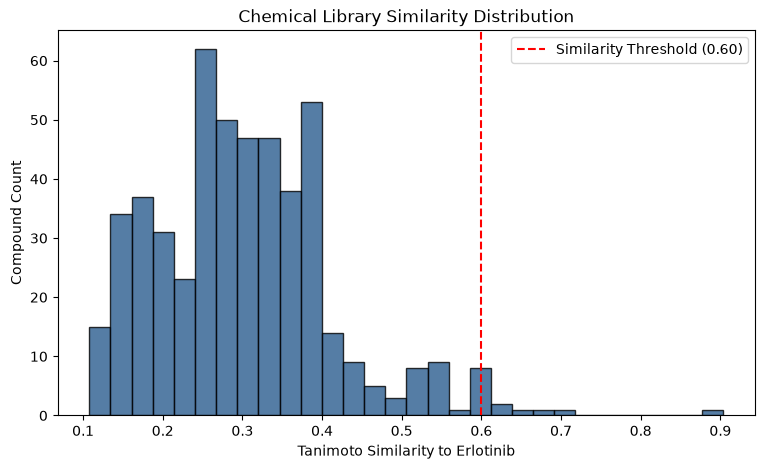

In [7]:
query_fp = mfpgen.GetFingerprint(Chem.MolFromSmiles(erlotinib_smi))
all_sims = np.array(DataStructs.BulkTanimotoSimilarity(query_fp, lib_fps))

num_high_sim = np.sum(all_sims >= 0.60)
print(f"Molecules with Tanimoto >= 0.60: {num_high_sim}")
print(f"Mean similarity:                {np.mean(all_sims):.4f}")
print(f"Maximum similarity:             {np.max(all_sims):.4f}")

plt.figure(figsize=(9, 5))
plt.hist(all_sims, bins=30, color="#2b5c8f", edgecolor="black", alpha=0.8)
plt.axvline(0.60, color="red", linestyle="--", label="Similarity Threshold (0.60)")
plt.xlabel("Tanimoto Similarity to Erlotinib")
plt.ylabel("Compound Count")
plt.title("Chemical Library Similarity Distribution")
plt.legend()
plt.show()

## 7. Summary & Key Takeaways
* **Tanimoto Similarity** is the industry standard for chemical fingerprint comparison ($0.85+$ usually indicates analogous biological activity).
* **`BulkTanimotoSimilarity`** enables lightning-fast screening of hundreds of thousands of molecules in fractions of a second.
* **Similarity Maps** provide atom-level explainability for medicinal chemists, revealing which functional groups match the reference template.

**Next Up in Video 09:** **SMARTS & Substructure Searching** — identifying functional groups, searching pharmacophores, and highlighting matched sub-graphs!